In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [3]:
df=pd.read_csv("C:\\Users\\Shahzadi\\Desktop\\disease predictor\\diabaties\\diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


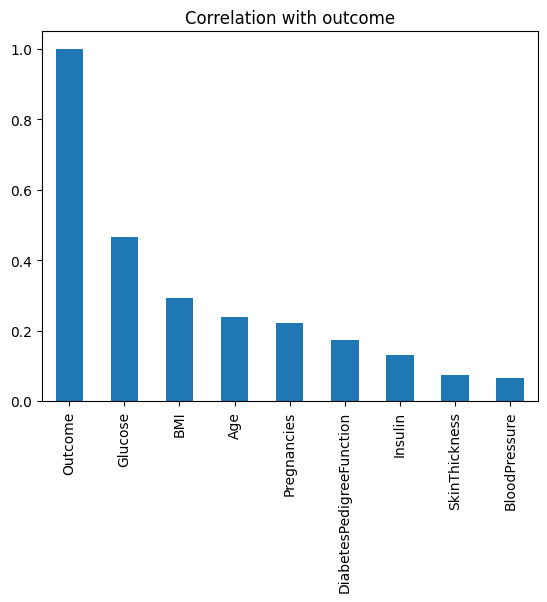

In [4]:
corr=df.corr(numeric_only=True)
corr_target=corr['Outcome'].sort_values(ascending=False)
corr_target.plot(kind='bar')
plt.title('Correlation with outcome')
plt.show()

In [5]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [8]:
xgb_model=XGBClassifier()
xgb_model.fit(x_train,y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [9]:
svm_model=SVC(probability=True)
svm_model.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [10]:
rf_model=RandomForestClassifier()
rf_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "SVM":                 svm_model,
    "Random Forest":       rf_model,
    "XGBoost":             xgb_model
}

results = {}

for name, model in models.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    results[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1-Score":  f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_prob)
    }


In [12]:
df_results = pd.DataFrame(results).T.round(4)
print(df_results)

               Accuracy  Precision  Recall  F1-Score  ROC-AUC
SVM              0.7532     0.6875    0.44    0.5366   0.7560
Random Forest    0.7597     0.6667    0.52    0.5843   0.7503
XGBoost          0.6818     0.5102    0.50    0.5051   0.7373


In [14]:
import joblib

# Find best model by ROC-AUC
best_name = max(results, key=lambda k: results[k]["ROC-AUC"])
best_model = models[best_name]

print(f"Best Model: {best_name}")
print(f"ROC-AUC:    {results[best_name]['ROC-AUC']:.4f}")

# Save model and scaler
joblib.dump(best_model, "best_disease_model.pkl")
# joblib.dump(scaler,     "disease_scaler.pkl")
print("Model saved → best_disease_model.pkl")
# print("Scaler saved → disease_scaler.pkl")

Best Model: SVM
ROC-AUC:    0.7560
Model saved → best_disease_model.pkl
